In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("train.csv", usecols=["Age", "Fare", "Survived"])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.shape

(891, 3)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [9]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [10]:
X = df.drop("Survived", axis = 1)
y = df["Survived"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=43)

In [13]:
X_train.head()

,Age,Fare
826,NaN,56.4958
838,32.0,56.4958
763,36.0,120.0000
189,36.0,7.8958
109,NaN,24.1500


In [14]:
X_train["Age_imputed"] = X_train["Age"]
X_test["Age_imputed"] = X_test["Age"]

In [15]:
X_train.head()

,Age,Fare,Age_imputed
826,NaN,56.4958,NaN
838,32.0,56.4958,32.0
763,36.0,120.0000,36.0
189,36.0,7.8958,36.0
109,NaN,24.1500,NaN


In [23]:
X_train["Age"].isnull().sum()

137

In [18]:
X_train["Age_imputed"][X_train["Age_imputed"].isnull()]

826   NaN
109   NaN
388   NaN
485   NaN
490   NaN
       ..
367   NaN
459   NaN
878   NaN
859   NaN
277   NaN
Name: Age_imputed, Length: 137, dtype: float64

In [20]:
X_train["Age"].dropna().sample(X_train["Age"].isnull().sum()).values

array([32.  , 44.  ,  0.42, 16.  ,  1.  , 20.  , 20.  , 21.  ,  0.75,
       23.  , 36.  , 40.5 , 49.  , 63.  , 23.  , 29.  , 31.  , 28.  ,
       10.  , 40.  , 42.  , 45.  , 37.  , 37.  , 34.  , 30.  , 39.  ,
       49.  , 29.  , 36.  ,  8.  , 18.  , 30.  , 40.  , 20.  , 64.  ,
       34.  , 24.  ,  2.  , 51.  , 24.  , 22.  , 11.  , 66.  , 24.  ,
       37.  ,  9.  , 30.  , 25.  , 21.  ,  2.  ,  4.  , 26.  , 42.  ,
       23.  , 20.  , 21.  , 33.  , 53.  , 24.  , 36.  , 61.  , 23.  ,
       28.  , 50.  , 32.  , 48.  , 21.  , 24.  , 31.  , 47.  , 39.  ,
       16.  , 27.  , 39.  , 38.  , 23.  ,  6.  , 16.  , 19.  , 17.  ,
       52.  , 30.  , 21.  , 35.  , 30.  , 24.  , 21.  , 31.  , 42.  ,
       18.  , 11.  , 29.  , 15.  ,  5.  , 15.  , 58.  , 27.  , 40.  ,
       40.  , 33.  , 29.  , 16.  , 39.  , 34.  , 32.  ,  9.  , 19.  ,
       55.5 , 19.  , 45.  , 35.  , 29.  , 18.  , 55.  , 25.  , 41.  ,
       33.  , 40.  , 29.  , 16.  , 29.  , 14.  , 21.  , 70.  , 33.  ,
       43.  ,  7.  ,

In [24]:
X_train["Age_imputed"][X_train["Age_imputed"].isnull()] = X_train["Age"].dropna().sample(X_train["Age"].isnull().sum()).values

In [25]:
X_test["Age_imputed"][X_test["Age_imputed"].isnull()] = X_test["Age"].dropna().sample(X_test["Age"].isnull().sum()).values

In [26]:
X_train.head()

,Age,Fare,Age_imputed
826,NaN,56.4958,36.0
838,32.0,56.4958,32.0
763,36.0,120.0000,36.0
189,36.0,7.8958,36.0
109,NaN,24.1500,18.0


C:\Users\kumar\AppData\Local\Temp\ipykernel_1856\318244464.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Age"], label = "Original", hist=False)
C:\Users\kumar\AppData\Local\Temp\ipykernel_1856\318244464.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[

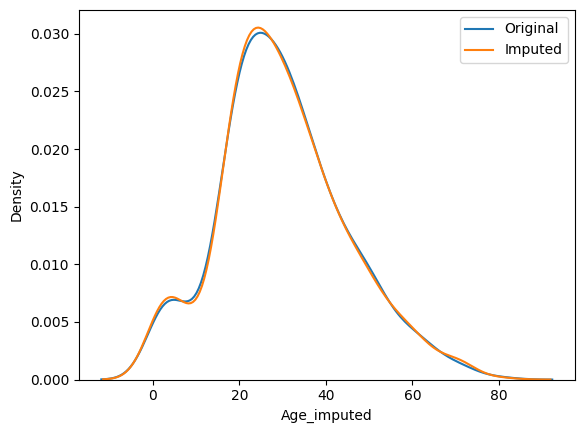

In [28]:
sns.distplot(X_train["Age"], label = "Original", hist=False)
sns.distplot(X_train["Age_imputed"], label = "Imputed", hist=False)

plt.legend()
plt.show()

In [30]:
print("Original Age variance: ", X_train["Age"].var())
print("Imputed Age variance: ", X_train["Age_imputed"].var())

Original Age variance:  213.11008686138464
Imputed Age variance:  216.70318614528517


In [31]:
X_train[["Age", "Fare", "Age_imputed"]].cov()

,Age,Fare,Age_imputed
Age,213.110087,77.843936,213.110087
Fare,77.843936,2714.150570,59.571293
Age_imputed,213.110087,59.571293,216.703186


<Axes: >

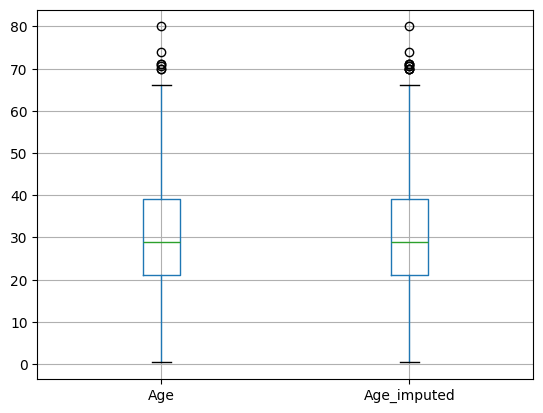

In [32]:
X_train[["Age", "Age_imputed"]].boxplot()

In [46]:
#sampled_value = X_train["Age"].dropna().sample(1, random_state=int(observation["Fare"])) #we can use this on production

In [43]:
sampled_value

649    23.0
Name: Age, dtype: float64

In [33]:
# Now working with categorical values

In [36]:
data = pd.read_csv("house-train.csv", usecols=["GarageQual", "FireplaceQu", "SalePrice"])

In [37]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FireplaceQu  770 non-null    object
 1   GarageQual   1379 non-null   object
 2   SalePrice    1460 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 34.3+ KB


In [39]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [72]:
X = data
y = data["SalePrice"]

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

In [74]:
X_train.head()

,FireplaceQu,GarageQual,SalePrice
676,NaN,Fa,87000
990,TA,TA,348000
71,NaN,TA,129500
979,NaN,TA,139000
946,TA,TA,143000


In [75]:
X_train["GarageQual_imputed"] = X_train["GarageQual"]
X_test["GarageQual_imputed"] = X_test["GarageQual"]

X_train["FireplaceQu_imputed"] = X_train["FireplaceQu"]
X_test["FireplaceQu_imputed"] = X_test["FireplaceQu"]

In [76]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1452,NaN,TA,145000,TA,NaN
294,Gd,TA,167000,TA,Gd
157,Gd,TA,269500,TA,Gd
503,TA,TA,289000,TA,TA
91,NaN,TA,98600,TA,NaN


In [77]:
X_train["GarageQual_imputed"][X_train["GarageQual_imputed"].isnull()] = X_train["GarageQual"].dropna().sample(X_train["GarageQual"].isnull().sum()).values
X_test["GarageQual_imputed"][X_test["GarageQual_imputed"].isnull()] = X_test["GarageQual"].dropna().sample(X_test["GarageQual"].isnull().sum()).values

C:\Users\kumar\AppData\Local\Temp\ipykernel_1856\2056994485.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["GarageQual_imputed"][X_train["GarageQual_imputed"].isnull()] = X_train["GarageQual"].dropna().sample(X_train["GarageQual"].isnull().sum()).values
C:\Users\kumar\AppData\Local\Temp\ipykernel_1856\2056994485.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["GarageQual_imputed"][X_test["GarageQual_imputed"].isnull()] = X_test["GarageQual"].dropna().sample(X_test["GarageQual"].isnull().sum()).values


In [78]:
X_train["FireplaceQu_imputed"][X_train["FireplaceQu_imputed"].isnull()] = X_train["FireplaceQu"].dropna().sample(X_train["FireplaceQu"].isnull().sum()).values
X_test["FireplaceQu_imputed"][X_test["FireplaceQu_imputed"].isnull()] = X_test["FireplaceQu"].dropna().sample(X_test["FireplaceQu"].isnull().sum()).values

C:\Users\kumar\AppData\Local\Temp\ipykernel_1856\2212147792.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["FireplaceQu_imputed"][X_train["FireplaceQu_imputed"].isnull()] = X_train["FireplaceQu"].dropna().sample(X_train["FireplaceQu"].isnull().sum()).values
C:\Users\kumar\AppData\Local\Temp\ipykernel_1856\2212147792.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["FireplaceQu_imputed"][X_test["FireplaceQu_imputed"].isnull()] = X_test["FireplaceQu"].dropna().sample(X_test["FireplaceQu"].isnull().sum()).values


In [79]:
temp = pd.concat([
    X_train["GarageQual"].value_counts()/(len(X_train["GarageQual"].dropna())),
    X_train["GarageQual_imputed"].value_counts()/(len(X_train))
], axis=1)

temp.columns = ["Original", "imputed"]

In [80]:
temp.head()

,Original,imputed
TA,0.952813,0.951199
Fa,0.033575,0.035959
Gd,0.009074,0.008562
Ex,0.002722,0.002568
Po,0.001815,0.001712


In [81]:
temp1 = pd.concat([
    X_train["FireplaceQu"].value_counts()/(len(X_train["FireplaceQu"].dropna())),
    X_train["FireplaceQu_imputed"].value_counts()/(len(X_train))
], axis=1)

temp1.columns = ["Original", "imputed"]

In [82]:
temp1

,Original,imputed
Gd,0.504902,0.502568
TA,0.400327,0.402397
Fa,0.040850,0.041096
Ex,0.029412,0.029110
Po,0.024510,0.024829


C:\Users\kumar\AppData\Local\Temp\ipykernel_1856\108495150.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train["FireplaceQu"]==category]["SalePrice"], hist = False, label=category)
C:\Users\kumar\AppData\Local\Temp\ipykernel_1856\108495150.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6

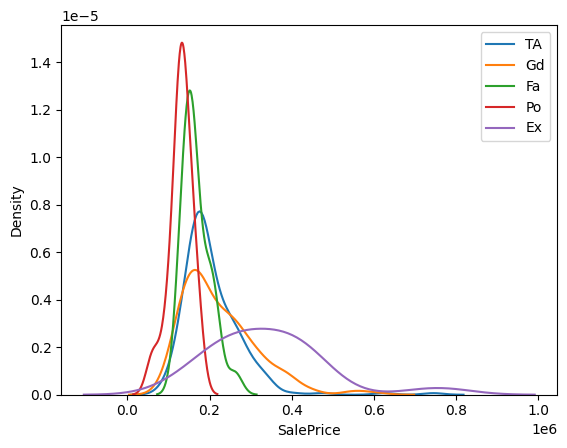

In [84]:
for category in X_train["FireplaceQu"].dropna().unique():
    sns.distplot(X_train[X_train["FireplaceQu"]==category]["SalePrice"], hist = False, label=category)
plt.legend()
plt.show()

C:\Users\kumar\AppData\Local\Temp\ipykernel_1856\1156906837.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train["FireplaceQu_imputed"]==category]["SalePrice"], hist = False, label=category)
C:\Users\kumar\AppData\Local\Temp\ipykernel_1856\1156906837.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed

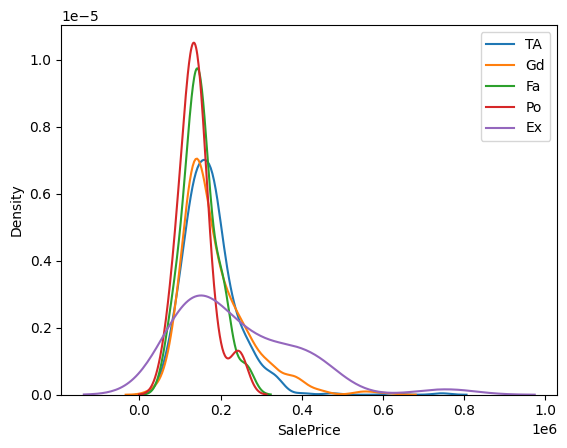

In [85]:
for category in X_train["FireplaceQu"].dropna().unique():
    sns.distplot(X_train[X_train["FireplaceQu_imputed"]==category]["SalePrice"], hist = False, label=category)
plt.legend()
plt.show()